# Phase 4: Expirementation with Kronecker Sequences

First we must import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
import matplotlib.ticker as mtick
from collections import Counter
import itertools
from dataclasses import dataclass, asdict



# Import Calculations for Zaremba Index
from math_help import rho_box1_numpy, rho_box_bruteforce, rho_box_lyness, rho_3d_lyness, rho_3d_lyness_corrected,  generate_optimized_g_vectors_3d, rho_4d_lyness, rho_5d_lyness, generate_optimized_g_vectors_4d, generate_optimized_g_vectors_5d

# Import Dataframe Helper
from experiment import bound_sufficiency_df

From the old study we know that - $\frac{C_d N}{(\log N)^{d-1}}$ : Is more of a theoretical lower-bound scale / existence-type benchmark

Our goal is to:
- Understand the distribution of $\rho_d(N,g)$
- Understand how the worst, median, and possibly upper quantiles behave w/ N
- Compare empirical behaviour against theoretical scaling
- Do this in 3D, 4D, and 5D

First let's setup the basic helper functions that are going to be using for this experiment


In [6]:
DELTA = 0.5   # any δ > 0 works; 0.5 is a common choice
C = 1.0  # placeholder — treat the bound as up to a constant factor

def psi(N: int) -> float:
    """ψ(N) = (log N)(log log N)^(1+δ) for N >= 3, else 1"""
    if N < 3:
        return 1.0
    log_N = np.log(N)
    log_log_N = np.log(log_N)
    return log_N * (log_log_N ** (1 + DELTA))


def rho_lower_bound(N: int, d: int) -> float:
    """Lower bound: ρ_d(N, α) >= cN / ψ(N)^(d-1)"""
    return (C * N) / (psi(N) ** (d - 1))

In [2]:
def analyze_rho_distribution(N_values, d=3):
    """
    Calculates the rho values for optimized g vectors, accounting for symmetry weights.
    Returns a summary DataFrame with quartiles and a dictionary of raw data for histograms.
    """
    stats_list = []
    distribution_data = {} 
    
    print(f"Starting Rho Distribution Analysis for {d}D...\n")
    
    for N in N_values:
        rho_values = []
        
        # Iterate through the optimized search space
        # Using 3D as the default based on the previous cells
        for g_vector, weight in generate_optimized_g_vectors_3d(N):
            alpha_vector = (g_vector[1] / N, g_vector[2] / N)
            actual_rho, _ = rho_3d_lyness_corrected(N, alpha_vector)
            
            # Crucial: Account for symmetry! 
            # Multiply the single observation by its weight to maintain true distribution density
            rho_values.extend([actual_rho] * weight) 
            
        # Convert to numpy array for fast statistical operations
        rho_array = np.array(rho_values)
        
        # Store raw data in a DataFrame for easy histogram plotting later
        distribution_data[N] = pd.DataFrame({'rho': rho_array})
        
        # Calculate percentiles and bounds
        min_rho = np.min(rho_array)
        q1 = np.percentile(rho_array, 25)
        median_rho = np.median(rho_array) # The exact bound where 50% pass
        q3 = np.percentile(rho_array, 75)
        max_rho = np.max(rho_array)
        
        stats_list.append({
            'N': N,
            'Min': min_rho,
            '25th Percentile (Q1)': q1,
            'Median (50% Bound)': median_rho,
            '75th Percentile (Q3)': q3,
            'Max': max_rho,
            'Total Vectors': len(rho_array)
        })
        
        print(f"--- N = {N} ---")
        print(f"Empirical 50% Bound (Median): {median_rho:.4f}")
        
    stats_df = pd.DataFrame(stats_list)
    return stats_df, distribution_data

# Define the prime N values you want to test
N_targets = [101, 251, 503, 1009]

# Run the analysis
distribution_stats_df, raw_distributions = analyze_rho_distribution(N_targets)

# Display the summary table
display(distribution_stats_df)

Starting Rho Distribution Analysis for 3D...

--- N = 101 ---
Empirical 50% Bound (Median): 4.0000
--- N = 251 ---
Empirical 50% Bound (Median): 6.0000
--- N = 503 ---
Empirical 50% Bound (Median): 10.0000
--- N = 1009 ---
Empirical 50% Bound (Median): 16.0000


,N,Min,25th Percentile (Q1),Median (50% Bound),75th Percentile (Q3),Max,Total Vectors
0,101,1.0,2.0,4.0,5.0,10.0,10000
1,251,1.0,4.0,6.0,9.0,20.0,62500
2,503,1.0,6.0,10.0,15.0,42.0,252004
3,1009,1.0,9.0,16.0,24.0,74.0,1016064


In [9]:
rows = []
for N, df in raw_distributions.items():
    lb = rho_lower_bound(N, d=3)
    count_above = (df['rho'] >= lb).sum()
    count_below = (df['rho'] < lb).sum()
    total = len(df)
    rows.append({
        'N': N,
        'Lower Bound': round(lb, 4),
        'Count Above': count_above,
        '% Above': round(100 * count_above / total, 2),
        'Count Below': count_below,
        '% Below': round(100 * count_below / total, 2),
        'Total': total,
    })

bound_check_df = pd.DataFrame(rows)
display(bound_check_df)


,N,Lower Bound,Count Above,% Above,Count Below,% Below,Total
0,101,1.3257,9024,90.24,976,9.76,10000
1,251,1.6460,60024,96.04,2476,3.96,62500
2,503,2.1285,235224,93.34,16780,6.66,252004
3,1009,2.9158,982080,96.66,33984,3.34,1016064


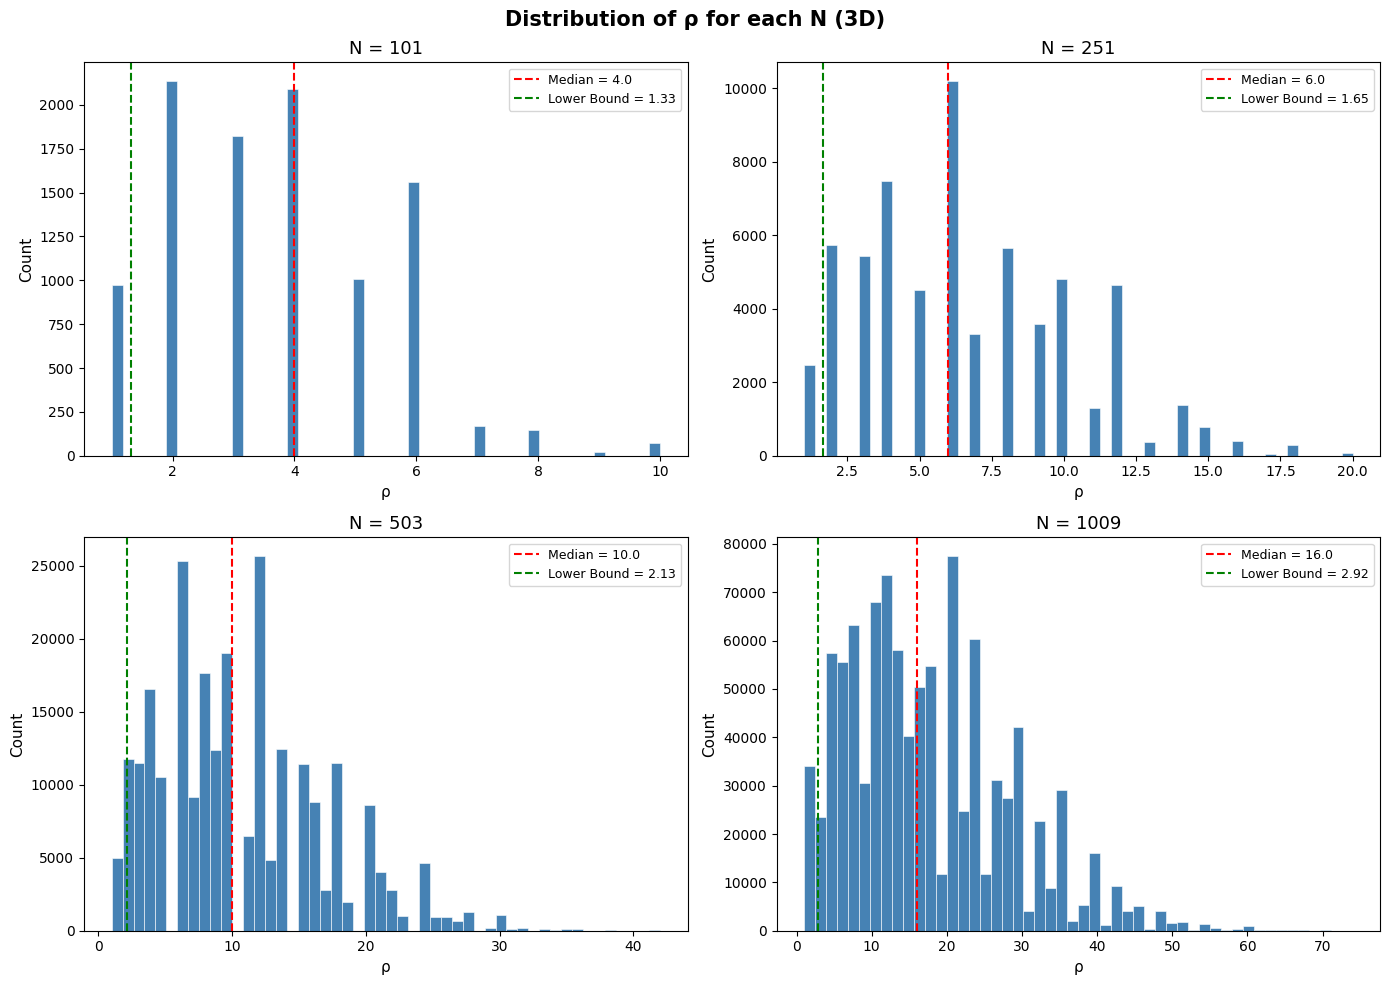

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (N, df) in enumerate(raw_distributions.items()):
    ax = axes[i]
    rho_vals = df['rho']
    lb = rho_lower_bound(N, d=3)

    ax.hist(rho_vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(rho_vals.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median = {rho_vals.median():.1f}')
    ax.axvline(lb, color='green', linestyle='--', linewidth=1.5, label=f'Lower Bound = {lb:.2f}')

    ax.set_title(f'N = {N}', fontsize=13)
    ax.set_xlabel('ρ', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Distribution of ρ for each N (3D)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
